<a href="https://colab.research.google.com/github/EmptyRain75/mnist-ai-classifier/blob/main/notebook/06_vit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Vision Transformer on MNIST

## Objective

Build a small Vision Transformer (ViT) to understand how an image
can be represented as a sequence of tokens and processed using
self-attention.

The focus is on understanding the architecture, tracking tensor
shapes, and connecting each component to its purpose.

Compared with the CNN stage, the main changes are:

- divide the image into patches,
- map patches into learned embeddings,
- add positional information,
- process tokens with Transformer encoder blocks,
- use a classification token to produce class logits.

We reuse MNIST, mini-batch training, Cross Entropy,
backpropagation, and train / validation / test evaluation.

## Module 1 — Load MNIST

We keep the same data setup as the MLP and CNN stages:

- 50,000 training images,
- 10,000 validation images,
- 10,000 test images,
- pixel values scaled to [0, 1].

Images remain spatial tensors at this stage:

    images: (batch_size, 1, 28, 28)
    labels: (batch_size,)

Patch extraction will happen inside the model later.

A fixed seed controls the train/validation split and training
shuffle. The split uses the same PyTorch procedure as the
previous MLP and CNN implementations.

In [1]:
import time
from pathlib import Path

import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms


SEED = 42
DATA_DIR = Path("/content/data")

torch.manual_seed(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("PyTorch version:", torch.__version__)
print("Device:", device)

PyTorch version: 2.11.0+cu130
Device: cuda


In [2]:
def load_mnist(batch_size=32, val_size=10000, seed=42):
    transform = transforms.ToTensor()

    full_train_dataset = datasets.MNIST(
        root=DATA_DIR,
        train=True,
        download=True,
        transform=transform,
    )

    test_dataset = datasets.MNIST(
        root=DATA_DIR,
        train=False,
        download=True,
        transform=transform,
    )

    train_dataset, val_dataset = random_split(
        full_train_dataset,
        [len(full_train_dataset) - val_size, val_size],
        generator=torch.Generator().manual_seed(seed),
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        generator=torch.Generator().manual_seed(seed),
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
    )

    return train_loader, val_loader, test_loader

100%|██████████| 9.91M/9.91M [00:00<00:00, 16.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 480kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.23MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.34MB/s]


Training samples: 50000
Validation samples: 10000
Test samples: 10000
Image batch shape: torch.Size([32, 1, 28, 28])
Label batch shape: torch.Size([32])
Pixel range: 0.0 1.0


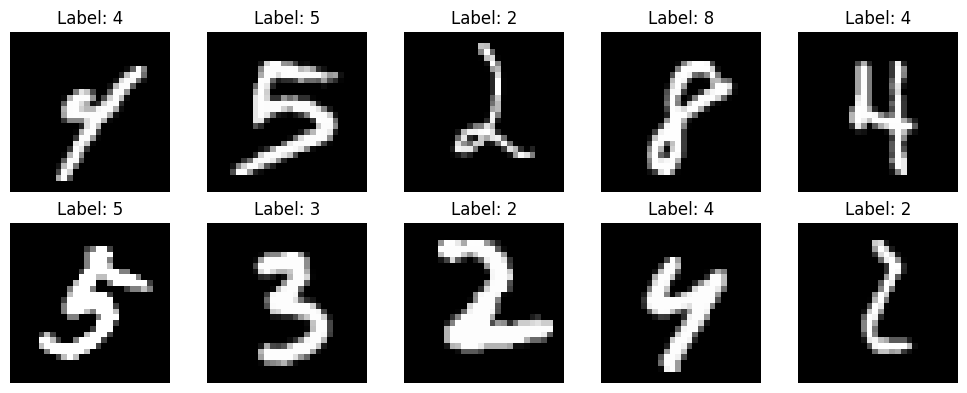

In [3]:
train_loader, val_loader, test_loader = load_mnist(
    batch_size=32,
    seed=SEED,
)

# Use validation data for inspection so the training shuffle
# generator is not advanced before training.
images, labels = next(iter(val_loader))

print("Training samples:", len(train_loader.dataset))
print("Validation samples:", len(val_loader.dataset))
print("Test samples:", len(test_loader.dataset))
print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Pixel range:", images.min().item(), images.max().item())

fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i, ax in enumerate(axes.flat):
    ax.imshow(images[i, 0], cmap="gray")
    ax.set_title(f"Label: {labels[i].item()}")
    ax.axis("off")

plt.tight_layout()
plt.show()

## Module 2 — Patch Extraction and Visualization

Instead of flattening the entire image into one vector, we divide
it into smaller, non-overlapping patches.

For a 28 × 28 image and patch size 7 × 7:

$$
N_{\text{patches}}
= \frac{28}{7}\times\frac{28}{7}
= 16
$$

Each grayscale patch contains:

$$
D_{\text{patch}} = 1\times7\times7 = 49
$$

Flattening each patch gives:

```text
Image                  Patch grid           Patch sequence
1 × 28 × 28       →    4 × 4 patches    →    16 × 49
```

For a batch:

```text
(B, 1, 28, 28) → (B, 16, 49)
```

Patches are ordered from left to right, then top to bottom.

At this stage, each patch vector contains raw pixel values.
The next module will learn a mapping from these 49 values to
a 64-dimensional embedding.

Unlike pooling, patch extraction does not discard pixel values.
We can reconstruct the original image exactly from these patches.

In [4]:
def extract_patches(images, patch_size=7):
    """Convert (B, C, H, W) images into (B, N, C*P*P) patches."""
    batch_size, channels, height, width = images.shape

    if patch_size <= 0:
        raise ValueError("patch_size must be positive.")

    if height % patch_size != 0 or width % patch_size != 0:
        raise ValueError("Image dimensions must be divisible by patch_size.")

    # (B, C, grid_h, grid_w, patch_h, patch_w)
    patches = (
        images
        .unfold(2, patch_size, patch_size)
        .unfold(3, patch_size, patch_size)
    )

    # Put patch-grid dimensions before each patch's pixel dimensions.
    # (B, grid_h, grid_w, C, patch_h, patch_w)
    patches = patches.permute(0, 2, 3, 1, 4, 5)

    # Flatten the grid into a sequence and each patch into a vector.
    patches = patches.reshape(
        batch_size,
        (height // patch_size) * (width // patch_size),
        channels * patch_size * patch_size,
    )

    return patches

In [5]:
patch_size = 7

patches = extract_patches(images, patch_size=patch_size)

print("Images:", images.shape)
print("Patches:", patches.shape)
print("Patches per image:", patches.shape[1])
print("Values per patch:", patches.shape[2])

assert patches.shape == (images.size(0), 16, 49)

Images: torch.Size([32, 1, 28, 28])
Patches: torch.Size([32, 16, 49])
Patches per image: 16
Values per patch: 49


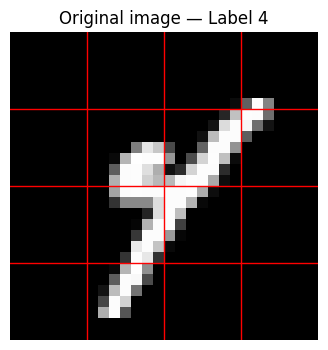

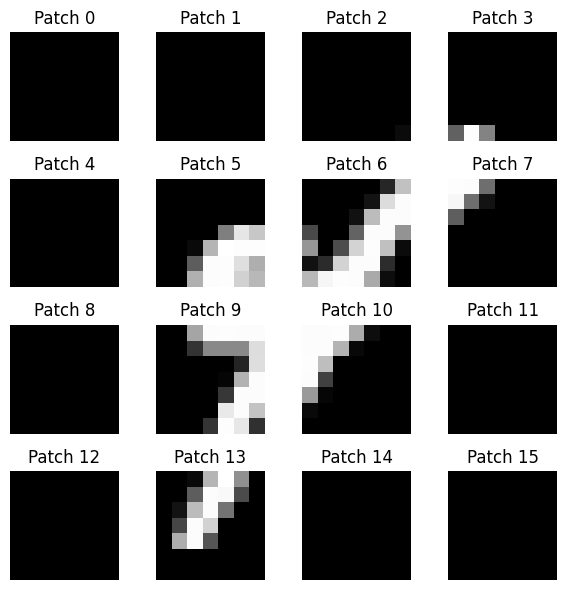

In [6]:
sample_index = 0

sample_image = images[sample_index, 0].cpu()
sample_patches = patches[sample_index].reshape(16, 7, 7).cpu()

# Original image with patch boundaries.
fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(sample_image, cmap="gray", vmin=0, vmax=1)

for boundary in range(patch_size, 28, patch_size):
    ax.axhline(boundary - 0.5, color="red", linewidth=1)
    ax.axvline(boundary - 0.5, color="red", linewidth=1)

ax.set_title(f"Original image — Label {labels[sample_index].item()}")
ax.axis("off")
plt.show()

# Patches arranged in their original spatial order.
fig, axes = plt.subplots(4, 4, figsize=(6, 6))

for i, ax in enumerate(axes.flat):
    ax.imshow(sample_patches[i], cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"Patch {i}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [7]:
batch_size, channels, height, width = images.shape
grid_h = height // patch_size
grid_w = width // patch_size

reconstructed = (
    patches
    .reshape(
        batch_size, grid_h, grid_w,
        channels, patch_size, patch_size,
    )
    .permute(0, 3, 1, 4, 2, 5)
    .reshape(batch_size, channels, height, width)
)

assert torch.equal(reconstructed, images)
print("Exact reconstruction:", torch.equal(reconstructed, images))

Exact reconstruction: True


### What Changed?

Softmax and MLP flatten the whole image into one vector of 784 values.

Here, we create a sequence of 16 vectors, each containing 49 values.
The total number of pixel values remains unchanged:

$$
16\times49 = 784
$$

Patch extraction has no trainable parameters. It defines the units
that the Transformer will process.

Next: map each raw patch vector into a learned embedding.

## Module 3 — Patch Embedding

Patch extraction gives a sequence of raw pixel vectors:

```text
(B, 16, 49)
```

The Transformer will process learned representations of these
patches. We use a linear projection to map each patch into a
64-dimensional embedding:

$$
e_i = x_i W_E + b_E
$$

where:

- $x_i \in \mathbb{R}^{49}$ is one flattened patch,
- $W_E \in \mathbb{R}^{49 \times 64}$ is the projection matrix,
- $b_E \in \mathbb{R}^{64}$ is the bias,
- $e_i \in \mathbb{R}^{64}$ is the patch embedding.

The shape changes as follows:

```text
Raw patches        Linear projection        Patch embeddings
(B, 16, 49)    →       49 → 64          →    (B, 16, 64)
```

The same projection is applied to every patch. We do not create
a separate linear layer for each patch position.

Each embedding feature is a learned weighted combination of
the pixels within that patch.

This operation processes patches independently. Interaction
between patches will happen later through self-attention.

In [8]:
class PatchEmbedding(nn.Module):
    def __init__(
        self,
        patch_size=7,
        in_channels=1,
        embed_dim=64,
    ):
        super().__init__()

        self.patch_size = patch_size
        patch_dim = in_channels * patch_size * patch_size

        self.projection = nn.Linear(patch_dim, embed_dim)

    def forward(self, images):
        patches = extract_patches(
            images,
            patch_size=self.patch_size,
        )

        return self.projection(patches)

In [9]:
# A demonstration module; the final ViT will create its own instance.
torch.manual_seed(SEED)

patch_embedding_demo = PatchEmbedding(
    patch_size=7,
    in_channels=1,
    embed_dim=64,
)

patch_embeddings = patch_embedding_demo(images)

print("Input images:", images.shape)
print("Raw patches:", patches.shape)
print("Patch embeddings:", patch_embeddings.shape)

print("\nProjection weight:", patch_embedding_demo.projection.weight.shape)
print("Projection bias:", patch_embedding_demo.projection.bias.shape)

parameter_count = sum(
    p.numel() for p in patch_embedding_demo.parameters()
)

print("Trainable parameters:", parameter_count)

assert patch_embeddings.shape == (images.size(0), 16, 64)
assert parameter_count == 49 * 64 + 64

Input images: torch.Size([32, 1, 28, 28])
Raw patches: torch.Size([32, 16, 49])
Patch embeddings: torch.Size([32, 16, 64])

Projection weight: torch.Size([64, 49])
Projection bias: torch.Size([64])
Trainable parameters: 3200


### Understanding the Weight Shape

Our row-vector equation uses:

$$
e_i = x_i W_E + b_E
$$

with $W_E$ shaped $(49, 64)$.

PyTorch stores the weight matrix transposed, with shape $(64, 49)$,
and computes:

$$
e_i = x_i W_{\text{torch}}^T + b_E
$$

These are the same calculation.

The parameter count is:

$$
49\times64 + 64 = 3200
$$

It does not depend on the number of patches because all patches
share the same projection.

In [11]:
first_patch = patches[0, 0]

weight = patch_embedding_demo.projection.weight
bias = patch_embedding_demo.projection.bias

manual_embedding = first_patch @ weight.T + bias
module_embedding = patch_embeddings[0, 0]

print("Manual embedding shape:", manual_embedding.shape)
print(
    "Maximum absolute difference:",
    (manual_embedding - module_embedding).abs().max().item(),
)

assert torch.allclose(
    manual_embedding,
    module_embedding,
    atol=1e-6,
    rtol=1e-5,
)

Manual embedding shape: torch.Size([64])
Maximum absolute difference: 0.0


### Key Takeaways

- Patch extraction reorganizes pixels without learning parameters.
- Patch embedding learns a representation of each patch.
- All patch positions share one linear projection.
- The sequence length remains 16; the feature dimension becomes 64.
- Embeddings are initially untrained and will learn through the
  classification loss.
- Patch embeddings do not yet explicitly encode their grid positions.

Next, we add a classification token and positional embeddings.

## Module 4 — Classification Token and Positional Embeddings

Our patch embeddings have shape:

```text
(B, 16, 64)
```

Before passing them into the Transformer encoder, we add:

1. A classification token (`CLS`).
2. Positional embeddings.

### Classification Token

The classification token is a trainable vector with 64 features.

We prepend it to each image's patch sequence:

```text
[CLS, Patch 0, Patch 1, ..., Patch 15]
```

The sequence length increases from 16 to 17:

```text
(B, 16, 64) → (B, 17, 64)
```

Every image starts with the same learned CLS vector. Through
self-attention, its representation becomes dependent on that
image's patch tokens.

After the encoder, we use the CLS representation as the input
to the classification head.

CLS is not a digit label or an extra image patch.

### Positional Embeddings

Patch projection applies the same transformation at every position.
Self-attention alone does not explicitly encode the order of the
patches.

We therefore learn a separate positional vector for each sequence
position, including CLS:

$$
E_{\text{pos}} \in \mathbb{R}^{1 \times 17 \times 64}
$$

We add it to the token sequence:

$$
Z_0 = [x_{\text{CLS}}; E_{\text{patches}}] + E_{\text{pos}}
$$

The positional vectors are shared across images, but differ across
sequence positions.

Adding positional information preserves the shape:

```text
(B, 17, 64) + (1, 17, 64) → (B, 17, 64)
```

The batch dimension is handled through broadcasting.

In [12]:
class TokenPreparation(nn.Module):
    def __init__(self, num_patches=16, embed_dim=64):
        super().__init__()

        self.num_patches = num_patches
        self.embed_dim = embed_dim

        self.cls_token = nn.Parameter(
            torch.zeros(1, 1, embed_dim)
        )

        self.position_embeddings = nn.Parameter(
            torch.zeros(1, num_patches + 1, embed_dim)
        )

        nn.init.normal_(self.cls_token, std=0.02)
        nn.init.normal_(self.position_embeddings, std=0.02)

    def forward(self, patch_embeddings):
        batch_size, num_patches, embed_dim = patch_embeddings.shape

        if num_patches != self.num_patches:
            raise ValueError("Unexpected number of patches.")

        if embed_dim != self.embed_dim:
            raise ValueError("Unexpected embedding dimension.")

        # Reuse the same learned CLS vector for every image.
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)

        # Prepend CLS along the sequence dimension.
        tokens = torch.cat(
            [cls_tokens, patch_embeddings],
            dim=1,
        )

        return tokens + self.position_embeddings

In [13]:
torch.manual_seed(SEED)

token_preparation_demo = TokenPreparation(
    num_patches=16,
    embed_dim=64,
)

input_tokens = token_preparation_demo(patch_embeddings)

print("Patch embeddings:", patch_embeddings.shape)
print("CLS parameter:", token_preparation_demo.cls_token.shape)
print(
    "Position parameters:",
    token_preparation_demo.position_embeddings.shape,
)
print("Encoder input:", input_tokens.shape)

parameter_count = sum(
    p.numel() for p in token_preparation_demo.parameters()
)

print("Trainable parameters:", parameter_count)

assert input_tokens.shape == (images.size(0), 17, 64)
assert parameter_count == 64 + 17 * 64

Patch embeddings: torch.Size([32, 16, 64])
CLS parameter: torch.Size([1, 1, 64])
Position parameters: torch.Size([1, 17, 64])
Encoder input: torch.Size([32, 17, 64])
Trainable parameters: 1152


In [14]:
# Sequence position 0 is CLS plus its positional embedding.
expected_cls = (
    token_preparation_demo.cls_token[0, 0]
    + token_preparation_demo.position_embeddings[0, 0]
)

assert torch.allclose(
    input_tokens[:, 0],
    expected_cls.unsqueeze(0).expand(images.size(0), -1),
)

# Sequence positions 1–16 are the patch embeddings plus positions.
expected_patch_tokens = (
    patch_embeddings
    + token_preparation_demo.position_embeddings[:, 1:]
)

assert torch.allclose(
    input_tokens[:, 1:],
    expected_patch_tokens,
)

print("CLS placement and positional addition verified.")

CLS placement and positional addition verified.


### What Has Been Learned So Far?

The trainable components before the encoder are:

| Component | Parameters |
|---|---:|
| Patch projection | 3,200 |
| CLS token | 64 |
| Positional embeddings | 1,088 |
| Total | 4,352 |

The CLS token and positional embeddings are model parameters.
Backpropagation updates them along with the projection weights.

Expanding CLS across the batch does not create a separate learned
parameter for each image. Gradients from the images contribute
to the same shared CLS parameter.

At this point, CLS has not yet gathered image information.
We have only assembled the sequence; token interaction begins
inside the Transformer encoder.

Next: self-attention and the Transformer encoder block.

## Module 5 — Transformer Encoder Block

The encoder receives:

```text
(B, 17, 64)
```

It contains two main operations:

1. Multi-head self-attention: exchange information between tokens.
2. Feed-forward network: transform each token's features independently.

Both operations have residual connections and are preceded by
Layer Normalization. This arrangement is called pre-normalization.

### Self-Attention

From the normalized token representations $U$, learned projections
produce queries, keys, and values:

$$
Q = UW_Q,\qquad K = UW_K,\qquad V = UW_V
$$

Bias terms are omitted here for readability.

For one attention head:

$$
A = \operatorname{softmax}
\left(\frac{QK^T}{\sqrt{d_h}}\right)
$$

$$
O = AV
$$

Each query token receives a weighted combination of value vectors.
Softmax is applied across the key-token dimension.

Queries and keys determine the attention weights; values supply
the information being combined.

### Multiple Heads

Our embedding dimension is 64, with 4 heads:

$$
d_h = \frac{64}{4} = 16
$$

Each head computes its own attention using learned projections.

The head outputs are concatenated and passed through an output
projection, returning to 64 features per token.

```text
Token sequence:      (B, 17, 64)
Q, K, V per head:    (B, 4, 17, 16)
Attention weights:   (B, 4, 17, 17)
Attention output:    (B, 17, 64)
```

All 17 tokens can attend to all 17 tokens, including themselves.
No causal mask is needed for this image classifier.

### Feed-Forward Network

The same small MLP is applied independently to each token:

```text
64 → Linear → 128 → GELU → Linear → 64
```

Attention mixes information across tokens.
The feed-forward network transforms features within each token.

### Complete Block

$$
Z' = Z + \operatorname{MSA}(\operatorname{LN}_1(Z))
$$

$$
Z_{\text{out}}
= Z' + \operatorname{FFN}(\operatorname{LN}_2(Z'))
$$

Residual connections add each branch's input to its output.
They provide a direct path for information and gradients.

LayerNorm(64) normalizes the 64 features of each token separately,
then applies learned scale and bias parameters.

The block preserves the sequence shape:

```text
(B, 17, 64) → (B, 17, 64)
```

In [15]:
class TransformerBlock(nn.Module):
    def __init__(
        self,
        embed_dim=64,
        num_heads=4,
        mlp_dim=128,
    ):
        super().__init__()

        if embed_dim % num_heads != 0:
            raise ValueError("embed_dim must be divisible by num_heads.")

        self.norm1 = nn.LayerNorm(embed_dim)

        self.attention = nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            dropout=0.0,
            batch_first=True,
        )

        self.norm2 = nn.LayerNorm(embed_dim)

        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, mlp_dim),
            nn.GELU(),
            nn.Linear(mlp_dim, embed_dim),
        )

    def forward(self, tokens, return_attention=False):
        normalized_tokens = self.norm1(tokens)

        attention_output, attention_weights = self.attention(
            normalized_tokens,
            normalized_tokens,
            normalized_tokens,
            need_weights=return_attention,
            average_attn_weights=False,
        )

        tokens = tokens + attention_output
        tokens = tokens + self.ffn(self.norm2(tokens))

        if return_attention:
            return tokens, attention_weights

        return tokens

In [16]:
torch.manual_seed(SEED)

encoder_block_demo = TransformerBlock(
    embed_dim=64,
    num_heads=4,
    mlp_dim=128,
)

encoder_block_demo.eval()

with torch.no_grad():
    output_tokens, attention_weights = encoder_block_demo(
        input_tokens,
        return_attention=True,
    )

print("Input tokens:", input_tokens.shape)
print("Output tokens:", output_tokens.shape)
print("Attention weights:", attention_weights.shape)

parameter_count = sum(
    p.numel() for p in encoder_block_demo.parameters()
)

print("Trainable parameters:", parameter_count)

assert output_tokens.shape == input_tokens.shape
assert attention_weights.shape == (images.size(0), 4, 17, 17)

# Each query has a probability distribution over the key tokens.
row_sums = attention_weights.sum(dim=-1)

assert torch.allclose(
    row_sums,
    torch.ones_like(row_sums),
    atol=1e-6,
)

print("Attention rows sum to 1.")

Input tokens: torch.Size([32, 17, 64])
Output tokens: torch.Size([32, 17, 64])
Attention weights: torch.Size([32, 4, 17, 17])
Trainable parameters: 33472
Attention rows sum to 1.


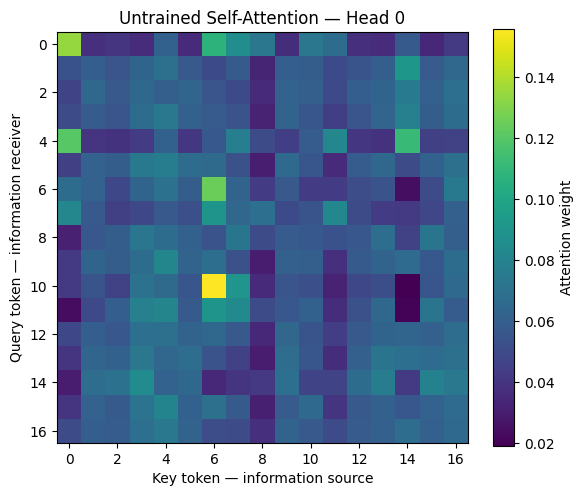

In [17]:
# First image, first attention head.
attention_matrix = attention_weights[0, 0].cpu()

plt.figure(figsize=(6, 5))
plt.imshow(
    attention_matrix,
    cmap="viridis",
    interpolation="nearest",
)

plt.xlabel("Key token — information source")
plt.ylabel("Query token — information receiver")
plt.title("Untrained Self-Attention — Head 0")
plt.colorbar(label="Attention weight")
plt.tight_layout()
plt.show()

### Reading the Attention Matrix

Each row represents one query token.
Each column represents one key token.

Entry $(i, j)$ is the weight used when query token $i$ combines
the value vector associated with token $j$.

Token 0 is CLS; tokens 1–16 correspond to patches 0–15.

The model is currently untrained. This visualization checks the
attention structure, not whether it has learned useful patterns.
Attention weights alone are also not a complete explanation
of a prediction.

### Parameter Count

| Component | Parameters |
|---|---:|
| Q, K, V projections, including biases | 12,480 |
| Attention output projection, including bias | 4,160 |
| Feed-forward network, including biases | 16,576 |
| Two LayerNorm modules | 256 |
| Total per encoder block | 33,472 |

The final ViT will stack two independently parameterized blocks.

After attention, CLS can contain image-dependent information.
The encoder preserves 17 tokens with 64 features each.

Next: assemble the complete ViT and map its final CLS
representation to 10 class logits.

## Module 6 — Complete Vision Transformer

The complete model follows this pipeline:

```text
Images                         (B, 1, 28, 28)
  ↓ Patch extraction
Raw patches                    (B, 16, 49)
  ↓ Linear projection
Patch embeddings               (B, 16, 64)
  ↓ Prepend CLS + add positions
Input tokens                   (B, 17, 64)
  ↓ Transformer block 1
Tokens                         (B, 17, 64)
  ↓ Transformer block 2
Tokens                         (B, 17, 64)
  ↓ Final LayerNorm
Normalized tokens              (B, 17, 64)
  ↓ Select CLS
Image representation           (B, 64)
  ↓ Linear classification head
Logits                         (B, 10)
```

The two encoder blocks have separate parameters.

After the encoder, we select sequence position 0:

$$
h_{\text{CLS}} = \operatorname{LN}(Z_L)[:, 0, :]
$$

The classification head computes:

$$
z = h_{\text{CLS}}W_{\text{head}} + b_{\text{head}}
$$

The output contains ten raw logits.

We do not apply Softmax inside the model. During training,
CrossEntropyLoss will receive these logits directly.

In [18]:
class ViT(nn.Module):
    def __init__(
        self,
        image_size=28,
        patch_size=7,
        in_channels=1,
        embed_dim=64,
        num_heads=4,
        mlp_dim=128,
        num_layers=2,
        num_classes=10,
    ):
        super().__init__()

        if patch_size <= 0 or image_size % patch_size != 0:
            raise ValueError(
                "patch_size must be positive and divide image_size."
            )

        self.image_size = image_size
        self.in_channels = in_channels

        num_patches = (image_size // patch_size) ** 2

        self.patch_embedding = PatchEmbedding(
            patch_size=patch_size,
            in_channels=in_channels,
            embed_dim=embed_dim,
        )

        self.token_preparation = TokenPreparation(
            num_patches=num_patches,
            embed_dim=embed_dim,
        )

        self.encoder_blocks = nn.ModuleList([
            TransformerBlock(
                embed_dim=embed_dim,
                num_heads=num_heads,
                mlp_dim=mlp_dim,
            )
            for _ in range(num_layers)
        ])

        self.final_norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, images):
        expected_shape = (
            self.in_channels,
            self.image_size,
            self.image_size,
        )

        if images.ndim != 4 or tuple(images.shape[1:]) != expected_shape:
            raise ValueError(
                f"Expected images shaped (B, {expected_shape}), "
                f"got {tuple(images.shape)}."
            )

        tokens = self.patch_embedding(images)
        tokens = self.token_preparation(tokens)

        for block in self.encoder_blocks:
            tokens = block(tokens)

        tokens = self.final_norm(tokens)

        cls_representation = tokens[:, 0]
        logits = self.head(cls_representation)

        return logits

In [19]:
# Create fresh parameters rather than reusing demonstration modules.
torch.manual_seed(SEED)

model = ViT(
    image_size=28,
    patch_size=7,
    in_channels=1,
    embed_dim=64,
    num_heads=4,
    mlp_dim=128,
    num_layers=2,
    num_classes=10,
).to(device)

print(model)

ViT(
  (patch_embedding): PatchEmbedding(
    (projection): Linear(in_features=49, out_features=64, bias=True)
  )
  (token_preparation): TokenPreparation()
  (encoder_blocks): ModuleList(
    (0-1): 2 x TransformerBlock(
      (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (attention): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
      )
      (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (ffn): Sequential(
        (0): Linear(in_features=64, out_features=128, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=128, out_features=64, bias=True)
      )
    )
  )
  (final_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (head): Linear(in_features=64, out_features=10, bias=True)
)


In [20]:
model.eval()

with torch.no_grad():
    sample_logits = model(images.to(device))

print("Input shape:", images.shape)
print("Logits shape:", sample_logits.shape)
print("First image logits:")
print(sample_logits[0].cpu())

assert sample_logits.shape == (images.size(0), 10)
assert torch.isfinite(sample_logits).all()

Input shape: torch.Size([32, 1, 28, 28])
Logits shape: torch.Size([32, 10])
First image logits:
tensor([-1.2067, -0.1514,  0.6563, -0.1337, -0.5097, -0.0307,  0.8494,  0.3608,
        -0.1466, -0.2669])


In [21]:
def count_parameters(module):
    return sum(
        parameter.numel()
        for parameter in module.parameters()
        if parameter.requires_grad
    )


components = {
    "Patch embedding": model.patch_embedding,
    "Token preparation": model.token_preparation,
    "Encoder blocks": model.encoder_blocks,
    "Final LayerNorm": model.final_norm,
    "Classification head": model.head,
}

for name, component in components.items():
    print(f"{name:<22}: {count_parameters(component):,}")

total_parameters = count_parameters(model)

print(f"\nTotal parameters: {total_parameters:,}")

assert total_parameters == 72074

Patch embedding       : 3,200
Token preparation     : 1,152
Encoder blocks        : 66,944
Final LayerNorm       : 128
Classification head   : 650

Total parameters: 72,074


### CNN → ViT: What Changed?

The CNN learns spatial feature maps through local convolutions
and pooling.

This ViT learns patch representations, then uses self-attention
to exchange information across the complete token sequence.

Both architectures produce a learned image representation
followed by a linear classifier.

| Component | CNN | ViT |
|---|---|---|
| Initial representation | Spatial image tensor | Sequence of patch embeddings |
| Feature processing | Convolution + ReLU + pooling | Attention + feed-forward networks |
| Position handling | Spatial arrangement and local operations | Added positional embeddings |
| Classifier input | Flattened feature maps | Final CLS representation |
| Output | 10 logits | 10 logits |

This basic ViT has 72,074 trainable parameters.
The previous baseline CNN has 50,186.

Parameter count alone does not determine accuracy or training
speed. The architectures perform different computations and
make different assumptions about image structure.

The model is now assembled, but its parameters are still untrained.
Next, we define the loss and optimizer, then train it on MNIST.

## Module 7 — Loss and Optimizer

### Cross Entropy

The ViT produces ten logits for each image:

```text
logits: (B, 10)
labels: (B,)
```

For sample $i$ with correct class $y_i$:

$$
L_i = -\log
\left(
\frac{\exp(z_{i,y_i})}
{\sum_{k=0}^{9}\exp(z_{i,k})}
\right)
$$

The batch loss is the mean of the sample losses.

We pass raw logits directly into `nn.CrossEntropyLoss()`.
It performs the equivalent of log-Softmax followed by
negative log-likelihood using a numerically stable calculation.

Labels remain integer class indices; explicit one-hot encoding
is unnecessary.

### Optimizer

We use Adam with a learning rate of 0.001.

Adam maintains moving averages of gradients and squared gradients
to adapt the updates for individual parameters.

This changes the parameter-update rule, while the training
sequence remains familiar:

```text
Forward pass
    ↓
Cross Entropy
    ↓
Clear previous gradients
    ↓
Backpropagation
    ↓
Optimizer update
```

### Baseline Configuration

| Setting | Value |
|---|---|
| Batch size | 32 |
| Epochs | 10 |
| Optimizer | Adam |
| Learning rate | 0.001 |
| Weight decay | 0 |
| Attention dropout | 0 |

The earlier MLP and CNN used SGD at 0.1.
Our comparison will therefore describe the recorded baseline
configurations; accuracy differences cannot be attributed
solely to architecture.

In [22]:
learning_rate = 0.001
n_epochs = 10

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=learning_rate,
    weight_decay=0.0,
)

print("Loss:", criterion)
print("Optimizer:", type(optimizer).__name__)
print("Learning rate:", learning_rate)
print("Epochs:", n_epochs)
print("Batch size:", train_loader.batch_size)

Loss: CrossEntropyLoss()
Optimizer: Adam
Learning rate: 0.001
Epochs: 10
Batch size: 32


In [23]:
model.eval()

with torch.no_grad():
    logits = model(images.to(device))
    initial_loss = criterion(
        logits,
        labels.to(device),
    )

print("Logits shape:", logits.shape)
print("Label dtype:", labels.dtype)
print("Initial loss:", initial_loss.item())

uniform_loss = torch.log(torch.tensor(10.0)).item()
print("Uniform-prediction reference:", uniform_loss)

assert torch.isfinite(initial_loss)

Logits shape: torch.Size([32, 10])
Label dtype: torch.int64
Initial loss: 2.438197135925293
Uniform-prediction reference: 2.3025851249694824


### Initial Loss

If a classifier assigns probability 0.1 to every class,
its Cross Entropy is:

$$
-\log(0.1) = \log(10) \approx 2.3026
$$

This is a useful reference, but our randomly initialized ViT
does not necessarily produce uniform probabilities.

Its initial loss therefore need not equal 2.3026.

No training update has been performed in this module.
The next module will run the training loop and record training
and validation behavior across epochs.

## Module 8 — Training Loop

For each training batch:

1. Move images and labels to the selected device.
2. Compute logits and Cross Entropy.
3. Clear gradients from the previous batch.
4. Backpropagate through the entire ViT.
5. Update parameters using Adam.

The loss trains all learned components together:

```text
Classification head
    ↓
Transformer encoder blocks
    ↓
CLS token and positional embeddings
    ↓
Patch projection
```

Patch extraction has no learned parameters.

After each epoch, evaluate the model on the validation set
without computing gradients or updating parameters.

We record:

- training loss,
- training accuracy,
- validation loss,
- validation accuracy.

Losses are weighted by batch size when calculating the epoch
average, so a smaller final batch receives the correct weight.

Training metrics are collected while parameters are changing.
Validation metrics are calculated using the model at the end
of the epoch.

We train for a fixed ten epochs and retain the final model.

In [24]:
def evaluate(model, data_loader, criterion, device):
    """Evaluate mean loss and accuracy without updating parameters."""
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            loss = criterion(logits, labels)

            batch_size = labels.size(0)

            total_loss += loss.item() * batch_size
            correct += (logits.argmax(dim=1) == labels).sum().item()
            total += batch_size

    return {
        "loss": total_loss / total,
        "accuracy": correct / total,
    }

In [25]:
def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    n_epochs=10,
):
    history = {
        "train_loss": [],
        "train_accuracy": [],
        "val_loss": [],
        "val_accuracy": [],
    }

    # Synchronize GPU work before starting the wall-clock timer.
    if device.type == "cuda":
        torch.cuda.synchronize(device)

    start_time = time.perf_counter()

    for epoch in range(n_epochs):
        model.train()

        total_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            logits = model(images)
            loss = criterion(logits, labels)

            loss.backward()
            optimizer.step()

            batch_size = labels.size(0)

            total_loss += loss.item() * batch_size
            correct += (logits.argmax(dim=1) == labels).sum().item()
            total += batch_size

        train_loss = total_loss / total
        train_accuracy = correct / total

        val_metrics = evaluate(
            model,
            val_loader,
            criterion,
            device,
        )

        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_accuracy)
        history["val_loss"].append(val_metrics["loss"])
        history["val_accuracy"].append(val_metrics["accuracy"])

        print(
            f"Epoch {epoch + 1:02d}/{n_epochs} | "
            f"Train loss: {train_loss:.4f} | "
            f"Train acc: {train_accuracy:.4f} | "
            f"Val loss: {val_metrics['loss']:.4f} | "
            f"Val acc: {val_metrics['accuracy']:.4f}"
        )

    if device.type == "cuda":
        torch.cuda.synchronize(device)

    elapsed_time = time.perf_counter() - start_time

    return history, elapsed_time

In [26]:
history, training_run_time = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    n_epochs=n_epochs,
)

print(f"\nTraining run time: {training_run_time:.2f} s")
print("Timing includes validation after each epoch.")
print("Device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(device))

Epoch 01/10 | Train loss: 0.4049 | Train acc: 0.8741 | Val loss: 0.1984 | Val acc: 0.9383
Epoch 02/10 | Train loss: 0.1538 | Train acc: 0.9534 | Val loss: 0.1661 | Val acc: 0.9463
Epoch 03/10 | Train loss: 0.1163 | Train acc: 0.9640 | Val loss: 0.1399 | Val acc: 0.9571
Epoch 04/10 | Train loss: 0.1023 | Train acc: 0.9677 | Val loss: 0.1336 | Val acc: 0.9596
Epoch 05/10 | Train loss: 0.0895 | Train acc: 0.9722 | Val loss: 0.1086 | Val acc: 0.9676
Epoch 06/10 | Train loss: 0.0760 | Train acc: 0.9757 | Val loss: 0.1091 | Val acc: 0.9669
Epoch 07/10 | Train loss: 0.0707 | Train acc: 0.9770 | Val loss: 0.0923 | Val acc: 0.9725
Epoch 08/10 | Train loss: 0.0595 | Train acc: 0.9811 | Val loss: 0.0887 | Val acc: 0.9737
Epoch 09/10 | Train loss: 0.0587 | Train acc: 0.9809 | Val loss: 0.0982 | Val acc: 0.9716
Epoch 10/10 | Train loss: 0.0525 | Train acc: 0.9824 | Val loss: 0.0900 | Val acc: 0.9724

Training run time: 179.02 s
Timing includes validation after each epoch.
Device: cuda
GPU: Tesla T4

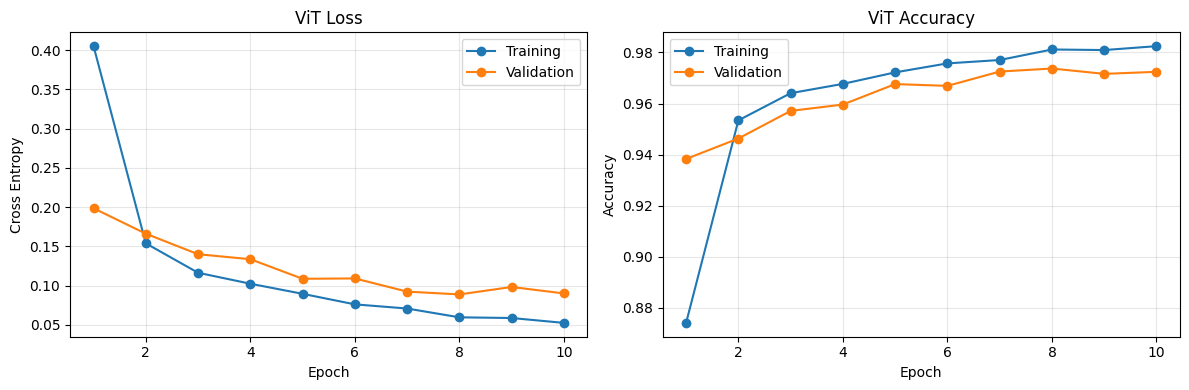

In [27]:
epochs = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(
    epochs, history["train_loss"],
    marker="o", label="Training",
)
axes[0].plot(
    epochs, history["val_loss"],
    marker="o", label="Validation",
)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross Entropy")
axes[0].set_title("ViT Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(
    epochs, history["train_accuracy"],
    marker="o", label="Training",
)
axes[1].plot(
    epochs, history["val_accuracy"],
    marker="o", label="Validation",
)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("ViT Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Reading the Learning Curves

Key Findings

Training Loss: Decreases steadily from 0.405 (Epoch 1) to 0.053 (Epoch 10), showing effective learning.

Validation Accuracy: Improves consistently, rising from 93.8% to a peak of 97.4% at Epoch 8, stabilizing around 97.3% at Epoch 10.

Validation Loss: Reaches its lowest point (~0.089) at Epoch 8 and plateaus with minor fluctuations (0.091–0.098) in Epochs 9–10.

Generalization & Overfitting: The performance gap between training and validation remains small (~0.9% accuracy diff at Epoch 10), indicating good generalization with minimal overfitting.

Train vs. Val Early Dynamics: Higher initial validation accuracy in Epoch 1 is expected due to validation occurring at end-of-epoch vs. training metrics averaged during update steps.

Conclusion

The ViT model achieves optimal generalization around Epochs 8–10 with >97.3% validation accuracy and no significant overfitting.

## Module 9 — Final Evaluation

After ten epochs, evaluate the final model on:

- training data,
- validation data,
- test data.

All three evaluations use fixed model parameters with gradient
computation disabled.

Unlike the training accuracy recorded during each epoch, final
training accuracy measures one fixed model over the training set.

The test set provides a final assessment of this baseline.
We do not use its results to select hyperparameters.

We also visualize predictions and inspect incorrect examples
to understand where the model struggles.

In [28]:
# Evaluate training data without advancing the training shuffle.
train_eval_loader = DataLoader(
    train_loader.dataset,
    batch_size=train_loader.batch_size,
    shuffle=False,
)

final_results = {}

for name, loader in {
    "Training": train_eval_loader,
    "Validation": val_loader,
    "Test": test_loader,
}.items():
    final_results[name] = evaluate(
        model,
        loader,
        criterion,
        device,
    )

print("Final ViT Results")
print("-----------------")

for name, metrics in final_results.items():
    print(
        f"{name:<10} | "
        f"Loss: {metrics['loss']:.4f} | "
        f"Accuracy: {metrics['accuracy']:.4f}"
    )

print(f"\nParameters: {count_parameters(model):,}")
print(f"Training run time: {training_run_time:.2f} s")
print("Runtime includes per-epoch validation.")
print("Device:", device)

Final ViT Results
-----------------
Training   | Loss: 0.0470 | Accuracy: 0.9842
Validation | Loss: 0.0900 | Accuracy: 0.9724
Test       | Loss: 0.0878 | Accuracy: 0.9745

Parameters: 72,074
Training run time: 179.02 s
Runtime includes per-epoch validation.
Device: cuda


In [29]:
def collect_predictions(model, data_loader, device):
    model.eval()

    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for images, labels in data_loader:
            logits = model(images.to(device))
            predictions = logits.argmax(dim=1)

            all_labels.append(labels.cpu())
            all_predictions.append(predictions.cpu())

    return (
        torch.cat(all_labels),
        torch.cat(all_predictions),
    )


test_labels, test_predictions = collect_predictions(
    model,
    test_loader,
    device,
)

correct_mask = test_predictions == test_labels

print("Correct predictions:", correct_mask.sum().item())
print("Incorrect predictions:", (~correct_mask).sum().item())

Correct predictions: 9745
Incorrect predictions: 255


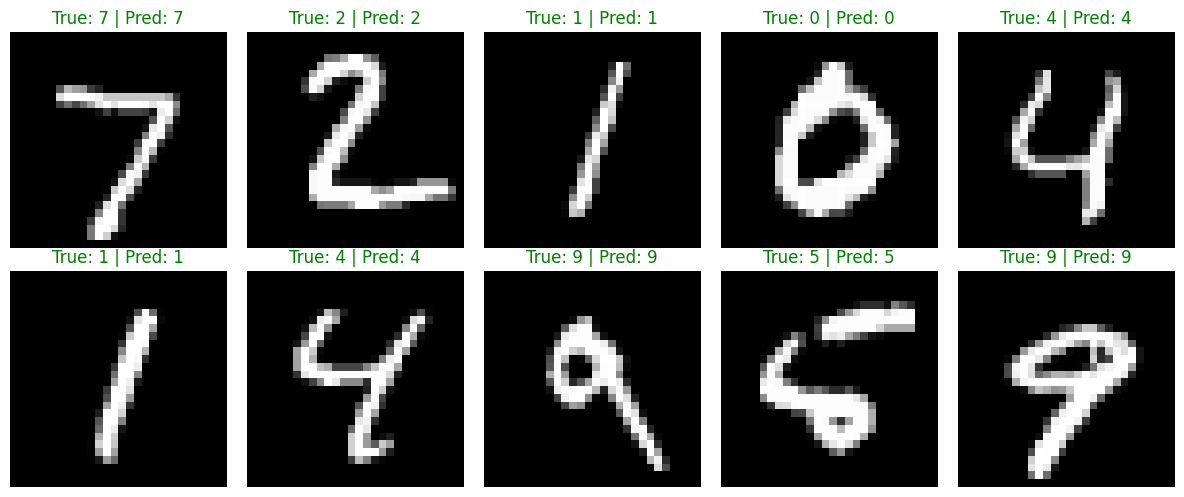

In [30]:
sample_images, sample_labels = next(iter(test_loader))

model.eval()

with torch.no_grad():
    sample_predictions = model(
        sample_images.to(device)
    ).argmax(dim=1).cpu()

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    true_label = sample_labels[i].item()
    predicted_label = sample_predictions[i].item()

    ax.imshow(sample_images[i, 0], cmap="gray")
    ax.set_title(
        f"True: {true_label} | Pred: {predicted_label}",
        color="green" if true_label == predicted_label else "red",
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

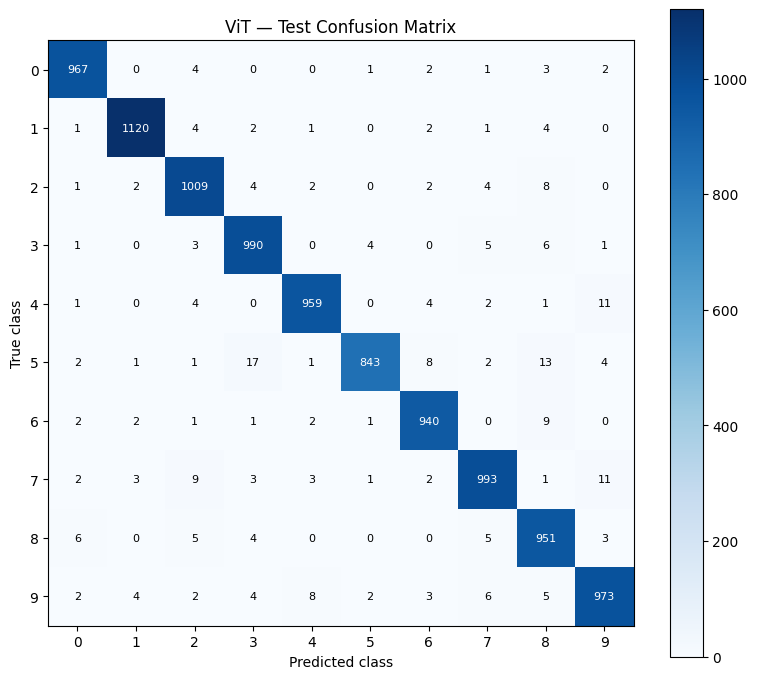

In [31]:
num_classes = 10

# Rows: true classes. Columns: predicted classes.
confusion_matrix = torch.bincount(
    test_labels * num_classes + test_predictions,
    minlength=num_classes ** 2,
).reshape(num_classes, num_classes)

fig, ax = plt.subplots(figsize=(8, 7))

image = ax.imshow(confusion_matrix.numpy(), cmap="Blues")

for true_class in range(num_classes):
    for predicted_class in range(num_classes):
        value = confusion_matrix[true_class, predicted_class].item()

        ax.text(
            predicted_class,
            true_class,
            str(value),
            ha="center",
            va="center",
            fontsize=8,
            color=(
                "white"
                if value > confusion_matrix.max().item() / 2
                else "black"
            ),
        )

ax.set_xticks(range(num_classes))
ax.set_yticks(range(num_classes))
ax.set_xlabel("Predicted class")
ax.set_ylabel("True class")
ax.set_title("ViT — Test Confusion Matrix")

fig.colorbar(image, ax=ax)
plt.tight_layout()
plt.show()

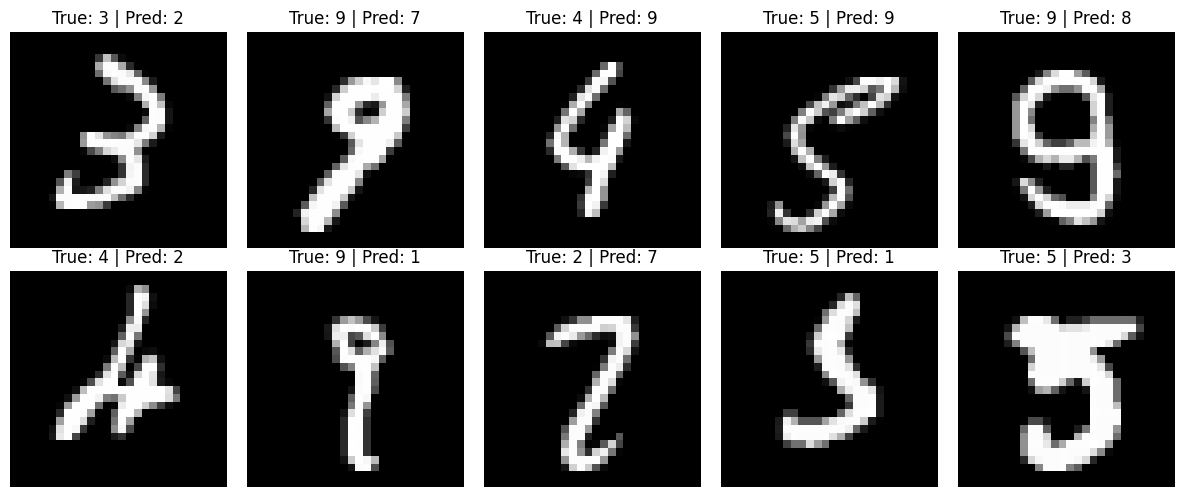

In [32]:
incorrect_indices = torch.where(~correct_mask)[0]
n_examples = min(10, len(incorrect_indices))

if n_examples == 0:
    print("No incorrect test predictions.")
else:
    fig, axes = plt.subplots(2, 5, figsize=(12, 5))

    for ax in axes.flat:
        ax.axis("off")

    for ax, index in zip(
        axes.flat,
        incorrect_indices[:n_examples].tolist(),
    ):
        # Predictions were collected in the test loader's fixed order.
        image, label = test_loader.dataset[index]
        prediction = test_predictions[index].item()

        ax.imshow(image[0], cmap="gray")
        ax.set_title(f"True: {label} | Pred: {prediction}")

    plt.tight_layout()
    plt.show()

### Evaluation Observations


#### 1. Training vs. Validation Accuracy
* **Gap:** Small ($\sim 1.0\%$). Final training accuracy reaches $\sim 98.3\%$ while validation accuracy is $\sim 97.3\%$.
* **Takeaway:** Minimal overfitting, the model demonstrates strong generalization capabilities.

#### 2. Validation vs. Test Performance
* **Comparison:** Highly consistent. Validation accuracy ($\sim 97.3\%$) matches test accuracy ($97.45\%$, with $9,745 / 10,000$ correct predictions).
* **Takeaway:** The model evaluates consistently on unseen test data without performance degradation.

#### 3. Most Frequently Confused Digit Pairs
* **True 5 $\rightarrow$ Predicted 3:** 17 instances (most common error)
* **True 5 $\rightarrow$ Predicted 8:** 13 instances
* **True 4 $\rightarrow$ Predicted 9:** 11 instances
* **True 7 $\rightarrow$ Predicted 9:** 11 instances

#### 4. Analysis of Incorrect Examples
* **Ambiguity:** Visual inspection of the first test errors confirms that misclassified samples exhibit ambiguous, heavily distorted, or atypical handwriting.
* **Examples:**
  * **True 4 $\rightarrow$ Pred 9:** Closed top loop making the digit look like a $9$.
  * **True 9 $\rightarrow$ Pred 7 / 1:** Extremely compressed top loops or straight vertical strokes.
  * **True 5 $\rightarrow$ Pred 9 / 3:** Distorted or fully curved segments mimicking a $9$ or $3$.

---
*Note: These observations apply specifically to this small Vision Transformer setup and configuration, not as a general benchmark against CNN architectures.*

## Module 10 — Architecture Comparison

The models differ mainly in how they build representations:

| Model | Representation | Main operation |
|---|---|---|
| Softmax Regression | Flattened raw pixels | Linear class scoring |
| MLP | Learned hidden features | Linear layers + nonlinear activation |
| CNN | Spatial feature maps | Local convolution + pooling |
| ViT | Patch-token representations | Self-attention + feed-forward networks |

### What Was Reused?

Across the MNIST models:

- classification into ten classes,
- Cross Entropy,
- gradient-based optimization,
- mini-batch training,
- training / validation / test evaluation.

### What Changed in ViT?

- Images became sequences of patch embeddings.
- Learned positional embeddings supplied position information.
- Self-attention enabled interaction across the token sequence.
- A classification token provided the final image representation.
- LayerNorm and residual connections supported encoder processing.

ViT is an alternative architecture to CNN, not a guaranteed
accuracy improvement.

In [33]:
# Recorded outputs from the previous notebooks.
# These models are not being retrained in this cell.
comparison_results = [
    {
        "model": "Softmax (NumPy, selected)",
        "parameters": 7850,
        "val_accuracy": 0.9205,
        "test_accuracy": 0.9254,
    },
    {
        "model": "MLP (128 hidden units)",
        "parameters": 101770,
        "val_accuracy": 0.9711,
        "test_accuracy": 0.9744,
    },
    {
        "model": "CNN (baseline)",
        "parameters": 50186,
        "val_accuracy": 0.9872,
        "test_accuracy": 0.9895,
    },
    {
        "model": "ViT (current run)",
        "parameters": count_parameters(model),
        "val_accuracy": final_results["Validation"]["accuracy"],
        "test_accuracy": final_results["Test"]["accuracy"],
    },
]

print(
    f"{'Model':<29}"
    f"{'Parameters':>12}"
    f"{'Val acc':>12}"
    f"{'Test acc':>12}"
)
print("-" * 65)

for result in comparison_results:
    print(
        f"{result['model']:<29}"
        f"{result['parameters']:>12,}"
        f"{result['val_accuracy']:>12.2%}"
        f"{result['test_accuracy']:>12.2%}"
    )

Model                          Parameters     Val acc    Test acc
-----------------------------------------------------------------
Softmax (NumPy, selected)           7,850      92.05%      92.54%
MLP (128 hidden units)            101,770      97.11%      97.44%
CNN (baseline)                     50,186      98.72%      98.95%
ViT (current run)                  72,074      97.24%      97.45%


### Interpreting the Comparison

This table summarizes recorded learning runs, rather than a
controlled experiment that changes architecture alone.

Important differences include:

- NumPy Softmax used a different train/validation split procedure.
- Softmax settings were selected through notebook experiments.
- The models used different training durations.
- MLP and CNN used SGD; ViT uses Adam.
- Initialization and execution conditions differ.

The MLP, CNN, and ViT use the same seeded PyTorch split procedure,
but their training configurations still differ.

We therefore use these results to describe the implemented
baselines and motivate architectural discussion.

Training times are omitted from the table because the runs used
different timing boundaries and may use different hardware.
The ViT runtime includes validation after every epoch.